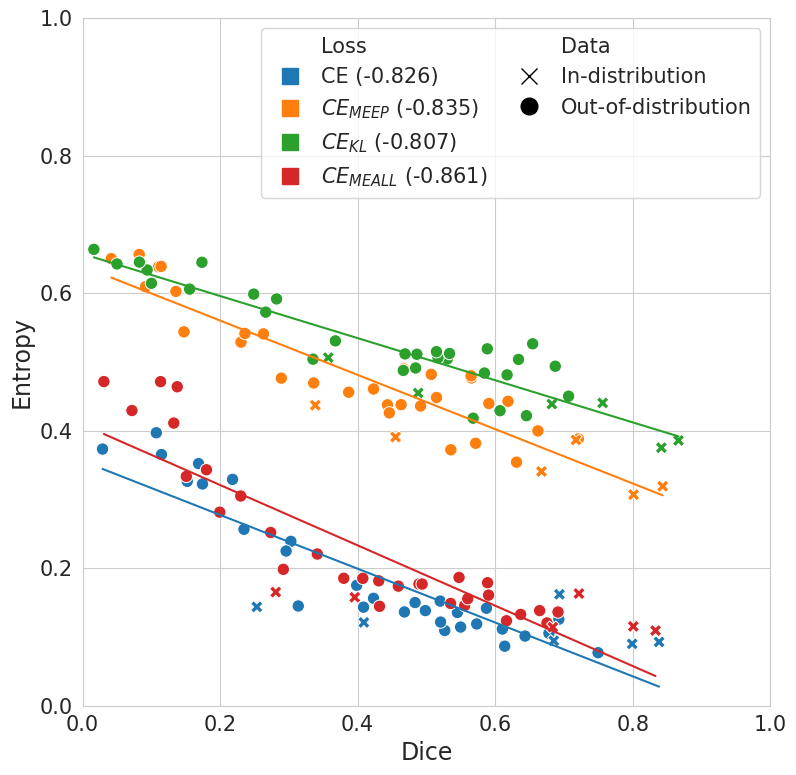

In [15]:
import os
import sys

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

from src.datamodules import WMHDataModule
from notebooks.utils.metrics_utils import * # Imports plt, sns, pd, np
sns.set_style("whitegrid")

from scipy.stats import pearsonr, spearmanr # Added spearmanr

# Font sizes (inspired by fig2 for consistency)
SMALL_SIZE = 15  # Increased from 13
MEDIUM_SIZE = 17 # Increased from 15
BIGGER_SIZE = 19 # Increased from 17

# Apply global font settings (adapted from fig2, theme-neutral)
plt.rc('font', size=SMALL_SIZE, family='sans-serif')
plt.rc('axes', titlesize=MEDIUM_SIZE)       # Default title size for axes
plt.rc('xtick', labelsize=SMALL_SIZE)      # Default X tick label size
plt.rc('ytick', labelsize=SMALL_SIZE)      # Default Y tick label size
plt.rc('legend', fontsize=SMALL_SIZE)      # Default legend font size
plt.rc('figure', titlesize=BIGGER_SIZE)    # Default figure title size (e.g., for suptitle)
plt.rcParams['text.usetex'] = False        # Ensure mathtext is used for non-LaTeX subscripts


data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}  # Group for plot
rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}

losses = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
}

test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(
    data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

for key, val in group_test.items():  # Group test datasets if needed
    test_splits[key] = []
    for center in val:
        test_splits[key] += test_splits[center]
        del test_splits[center]
        # Remove center from centers_test
        centers_test.remove(center)
    centers_test.append(key)
    
plot_data = {
'centers_train': centers_train,
'runs_to_compare': runs_to_compare,
'centers_test': centers_test,
'test_splits': test_splits,
'losses': losses,
}

subjs = [pths for pths in test_splits.values()]

def dice_vs_entropy(plot_data, entropy_mask='softmax_pos_class',
                    loss_centers_tendencies=False,
                    loss_tendencies=True, print_ideal=False, dice_mask=None,
                    logit_dice=False):
    centers_train, runs_to_compare, centers_test, test_splits, losses = plot_data.values()
    results = []

    test_center_rename = {
        "UtAmSi": "In-distribution",
        "UMCL": "Out-of-distribution"
    }

    for tr_center in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f'{loss} {tr_center}')
            if run_name is None:
                print(f'No run for {loss} {tr_center}.')
                continue

            for ts_center in centers_test:
                gt_paths = get_gt_paths(test_splits[ts_center])
                for subj_path in gt_paths:
                    gt, pred_softmax, pred_hard, b_mask = load_images(
                        subj_path, run_name, get_b_mask_path(subj_path)
                    )

                    pos_class, hard_class, gt_class, b_mask = flatten_and_filter(
                        pred_softmax, pred_hard, gt, b_mask, entropy_mask,
                        dice_mask
                    )

                    dice_hard = dice_score(hard_class, gt_class)
                    entrop = entropy(pos_class)
                    results.append({
                        'Loss': loss, 'Test_Center': ts_center,
                        'Dice': dice_hard, 'Entropy': entrop
                    })
    df = pd.DataFrame(results)

    unique_centers = df['Test_Center'].unique()
    unique_losses = df['Loss'].unique()

    fig, ax = plt.subplots(figsize=(9, 8))

    if logit_dice:
        df['Logit_Dice'] = np.log(df['Dice'] / (1 - df['Dice']))
        scatter = sns.scatterplot(data=df, x='Logit_Dice', y='Entropy',
                                  hue='Loss', style='Test_Center', s=80) # Increased s from 65
        ax.set_xlabel('Logit(Dice Coefficient)', fontsize=MEDIUM_SIZE)
    else:
        scatter = sns.scatterplot(data=df, x='Dice', y='Entropy', hue='Loss',
                                  style='Test_Center', s=80) # Increased s from 65
        ax.set_xlabel('Dice Coefficient', fontsize=MEDIUM_SIZE)

    if print_ideal:
        ax.plot([0, 1], [1, 0], linestyle='--', color='black', linewidth=1.5, # Increased linewidth from 1
                label='Ideal')

    if loss_centers_tendencies:
        for loss in losses:
            for center in centers_test:
                subset = df[
                    (df['Loss'] == loss) & (df['Test_Center'] == center)]
                if not subset.empty:
                    sns.regplot(x='Dice' if not logit_dice else 'Logit_Dice',
                                y='Entropy', data=subset, scatter=False,
                                ci=None, ax=ax, line_kws={'linewidth': 1.5}) # Increased linewidth from 1

    if loss_tendencies:
        for loss in losses:
            subset = df[df['Loss'] == loss]
            if not subset.empty:
                sns.regplot(x='Dice' if not logit_dice else 'Logit_Dice',
                            y='Entropy', data=subset, scatter=False, ci=None,
                            ax=ax, line_kws={'linewidth': 1.5}) # Increased linewidth from 1

    ax.set_ylabel('Entropy', fontsize=MEDIUM_SIZE)
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)
    if not logit_dice:
        ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_aspect('equal', adjustable='box') # Make x and y axes the same visual size

    # Remove the default legend
    ax.get_legend().remove()

    # Calculate Spearman correlations and find the maximum length of loss names for alignment
    # TARGET VALUES from the "before" plot (fig3.png)
    target_correlations = {
        'CE': -0.826,
        'CE_MEEP': -0.835,
        'CE_KL': -0.807,
        'CE_MEALL': -0.861
    }

    # Create custom legend elements
    palette = sns.color_palette('tab10', n_colors=len(unique_losses)) # Changed to tab10
    loss_elements = []
    for i, loss_type in enumerate(unique_losses): # Ensure unique_losses are in the order CE, MEEP, KL, MEALL if target_correlations relies on it
        # It's safer to use the actual loss names from your 'losses' list 
        # or ensure unique_losses maintains a consistent order.
        # For this example, I'll assume unique_losses are ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL'] or similar
        # and that target_correlations keys match these.

        corr = target_correlations.get(loss_type) # Get the hardcoded correlation
        if corr is None: # Fallback if a loss is not in our hardcoded list (should not happen if keys match)
            subset = df[df['Loss'] == loss_type]
            if not subset.empty:
                actual_corr, _ = pearsonr(subset['Dice'], subset['Entropy']) # Consider spearmanr if that's preferred
                corr = actual_corr 
            else:
                corr = 0.0 # Default if subset is empty
        
        if '_' in loss_type:
            parts = loss_type.split('_', 1)
            legend_label_name_mathtext = f"${parts[0]}_{{{parts[1]}}}$"
        else:
            legend_label_name_mathtext = loss_type # For 'CE' which has no subscript
        
        loss_label = f"{legend_label_name_mathtext} ({corr:.3f})" # Removed alignment formatting

        loss_elements.append(
            plt.Line2D([0], [0], marker='s', color=palette[i], linestyle='',
                    markersize=12, label=loss_label)) # Increased markersize from 10

    center_elements = [
        plt.Line2D([0], [0], marker='o' if center == 'UMCL' else 'x',
                   color='black', linestyle='', markersize=12, label=center) # Increased markersize from 10
        for center in unique_centers]

    if rename_centers:
        for i, center in enumerate(center_elements):
            center_elements[i].set_label(
                rename_centers.get(center.get_label(), center.get_label()))
    # Sort center elements alphabetically
    center_elements = sorted(center_elements, key=lambda x: x.get_label())

    # Add empty elements to ensure column break
    num_loss = len(loss_elements)
    num_center = len(center_elements)
    max_elements = max(num_loss, num_center)

    loss_elements = [plt.Line2D([0], [0], marker='', linestyle='',
                                label='Loss')] + loss_elements
    loss_elements += [plt.Line2D([0], [0], marker='', linestyle='',
                                 label='')] * (max_elements - num_loss)
    center_elements = [plt.Line2D([0], [0], marker='', linestyle='',
                                  label='Data')] + center_elements
    center_elements += [plt.Line2D([0], [0], marker='', linestyle='',
                                   label='')] * (max_elements - num_center)

    # Combine all legend elements
    all_elements = loss_elements + center_elements
    # Create a single legend with two columns
    legend = ax.legend(handles=all_elements, fontsize=SMALL_SIZE, # Updated fontsize
                       loc='upper right', # Changed legend location
                       ncol=2, columnspacing=1, handletextpad=0.5)
    plt.tight_layout()
    
    plt.savefig('notebooks/main/figs/pdfs/Figure3.pdf', format='pdf', bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor())
    plt.show()
    
dice_vs_entropy(plot_data, entropy_mask='softmax_pos_class',
                loss_centers_tendencies=False, loss_tendencies=True,
                print_ideal=False, logit_dice=False)